(np)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`NumPy <single: NumPy>`

```{index} single: Python; NumPy
```

```{epigraph}
"بیایید صریح باشیم: کار علم هیچ ربطی به اجماع ندارد. اجماع کار سیاست است. برعکس، علم فقط به یک محقق نیاز دارد که اتفاقاً درست بگوید، که به این معنی است که او نتایجی دارد که با ارجاع به دنیای واقعی قابل تأیید هستند. در علم، اجماع بی‌ربط است. آنچه مرتبط است، نتایج تکرارپذیر است." -- مایکل کرایتون
```

علاوه بر آنچه در Anaconda موجود است، این درس به کتابخانه‌های زیر نیاز دارد:

In [1]:
!pip install quantecon

## مروری کلی

[NumPy](https://en.wikipedia.org/wiki/NumPy) یک کتابخانه درجه یک برای برنامه‌نویسی عددی است

* به طور گسترده در دانشگاه‌ها، امور مالی و صنعت استفاده می‌شود.
* بالغ، سریع، پایدار و تحت توسعه مستمر است.

ما قبلاً در درس‌های قبلی کدهایی شامل NumPy دیده‌ایم.

در این درس، بحث سیستماتیک‌تری را در مورد موارد زیر آغاز خواهیم کرد:

1. آرایه‌های NumPy و
1. عملیات پردازش آرایه اساسی که توسط NumPy ارائه می‌شوند.


(برای یک مرجع جایگزین، به [مستندات رسمی NumPy](https://numpy.org/doc/stable/reference/) مراجعه کنید.)

ما از import های زیر استفاده خواهیم کرد.

In [2]:
import numpy as np
import random
import quantecon as qe
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm

(numpy_array)=
## آرایه‌های NumPy

```{index} single: NumPy; Arrays
```

مشکل اساسی که NumPy حل می‌کند، پردازش سریع آرایه است.

مهم‌ترین ساختاری که NumPy تعریف می‌کند، نوع داده آرایه است که به صورت رسمی
[numpy.ndarray](https://numpy.org/doc/stable/reference/arrays.ndarray.html) نامیده می‌شود.

آرایه‌های NumPy بخش بسیار بزرگی از اکوسیستم علمی Python را پشتیبانی می‌کنند.

### مبانی

برای ایجاد یک آرایه NumPy که فقط شامل صفر است از [np.zeros](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html#numpy.zeros) استفاده می‌کنیم

In [3]:
a = np.zeros(3)
a

array([0., 0., 0.])

In [4]:
type(a)

numpy.ndarray

آرایه‌های NumPy تا حدی شبیه لیست‌های بومی Python هستند، به جز اینکه

* داده‌ها *باید همگن باشند* (همه عناصر از یک نوع).
* این انواع باید یکی از [انواع داده](https://numpy.org/doc/stable/reference/arrays.dtypes.html) (`dtypes`) ارائه شده توسط NumPy باشند.

مهم‌ترین این dtypes عبارتند از:

* float64: عدد ممیز شناور 64 بیتی
* int64: عدد صحیح 64 بیتی
* bool: 8 بیتی True یا False

همچنین dtypes هایی برای نمایش اعداد مختلط، اعداد صحیح بدون علامت و غیره وجود دارد.

در ماشین‌های مدرن، dtype پیش‌فرض برای آرایه‌ها `float64` است

In [5]:
a = np.zeros(3)
type(a[0])

numpy.float64

اگر بخواهیم از اعداد صحیح استفاده کنیم، می‌توانیم به صورت زیر مشخص کنیم:

In [6]:
a = np.zeros(3, dtype=int)
type(a[0])

numpy.int64

(numpy_shape_dim)=
### شکل و بعد

```{index} single: NumPy; Arrays (Shape and Dimension)
```

انتساب زیر را در نظر بگیرید

In [7]:
z = np.zeros(10)

در اینجا `z` یک آرایه **مسطح** است --- نه بردار سطر و نه ستون.

In [8]:
z.shape

(10,)

در اینجا tuple شکل فقط یک عنصر دارد که طول آرایه است
(tuple های با یک عنصر با کاما پایان می‌یابند).

برای اضافه کردن یک بعد اضافی، می‌توانیم ویژگی `shape` را تغییر دهیم

In [9]:
z.shape = (10, 1)   # تبدیل آرایه مسطح به بردار ستونی (دو بعدی)
z

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [10]:
z = np.zeros(4)     # آرایه مسطح
z.shape = (2, 2)    # آرایه دو بعدی
z

array([[0., 0.],
       [0., 0.]])

در مورد آخر، برای ساخت آرایه 2×2، می‌توانیم یک tuple را نیز به تابع `zeros()` ارسال کنیم، مانند
`z = np.zeros((2, 2))`.



(creating_arrays)=
### ایجاد آرایه‌ها

```{index} single: NumPy; Arrays (Creating)
```

همان‌طور که دیده‌ایم، تابع `np.zeros` یک آرایه از صفرها ایجاد می‌کند.

احتمالاً می‌توانید حدس بزنید که `np.ones` چه چیزی ایجاد می‌کند.

مرتبط با آن `np.empty` است که آرایه‌هایی را در حافظه ایجاد می‌کند که بعداً می‌توان آن‌ها را با داده پر کرد

In [11]:
z = np.empty(3)
z

array([0., 0., 0.])

اعدادی که در اینجا می‌بینید مقادیر زباله هستند.

(Python سه قطعه متوالی 64 بیتی حافظه را اختصاص می‌دهد و محتویات موجود آن slot های حافظه به عنوان مقادیر `float64` تفسیر می‌شوند)

برای راه‌اندازی یک شبکه از اعداد با فاصله یکسان از `np.linspace` استفاده کنید

In [12]:
z = np.linspace(2, 4, 5)  # از 2 تا 4، با 5 عنصر

برای ایجاد یک ماتریس همانی از `np.identity` یا `np.eye` استفاده کنید

In [13]:
z = np.identity(2)
z

array([[1., 0.],
       [0., 1.]])

علاوه بر این، آرایه‌های NumPy را می‌توان از لیست‌های Python، tuple ها و غیره با استفاده از `np.array` ایجاد کرد

In [14]:
z = np.array([10, 20])                 # ndarray از لیست Python
z

array([10, 20])

In [15]:
type(z)

numpy.ndarray

In [16]:
z = np.array((10, 20), dtype=float)    # در اینجا 'float' معادل 'np.float64' است
z

array([10., 20.])

In [17]:
z = np.array([[1, 2], [3, 4]])         # آرایه 2 بعدی از یک لیست از لیست‌ها
z

array([[1, 2],
       [3, 4]])

همچنین `np.asarray` را ببینید که عملکرد مشابهی انجام می‌دهد، اما یک نسخه مجزا از داده‌های موجود در یک آرایه NumPy ایجاد نمی‌کند.

برای خواندن داده‌های آرایه از یک فایل متنی حاوی داده‌های عددی، از `np.loadtxt` استفاده کنید --- برای جزئیات به [مستندات](https://numpy.org/doc/stable/reference/routines.io.html) مراجعه کنید.

### نمایه‌گذاری آرایه

```{index} single: NumPy; Arrays (Indexing)
```

برای یک آرایه مسطح، نمایه‌گذاری مانند توالی‌های Python است:

In [18]:
z = np.linspace(1, 2, 5)
z

array([1.  , 1.25, 1.5 , 1.75, 2.  ])

In [19]:
z[0]

np.float64(1.0)

In [20]:
z[0:2]  # دو عنصر، از عنصر 0 شروع می‌شود

array([1.  , 1.25])

In [21]:
z[-1]

np.float64(2.0)

برای آرایه‌های دو بعدی، نحو نمایه به صورت زیر است:

In [22]:
z = np.array([[1, 2], [3, 4]])
z

array([[1, 2],
       [3, 4]])

In [23]:
z[0, 0]

np.int64(1)

In [24]:
z[0, 1]

np.int64(2)

و الی آخر.

ستون‌ها و سطرها را می‌توان به صورت زیر استخراج کرد

In [25]:
z[0, :]

array([1, 2])

In [26]:
z[:, 1]

array([2, 4])

آرایه‌های NumPy از اعداد صحیح نیز می‌توانند برای استخراج عناصر استفاده شوند

In [27]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [28]:
indices = np.array((0, 2, 3))
z[indices]

array([2. , 3. , 3.5])

در نهایت، یک آرایه از `dtype bool` می‌تواند برای استخراج عناصر استفاده شود

In [29]:
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [30]:
d = np.array([0, 1, 1, 0, 0], dtype=bool)
d

array([False,  True,  True, False, False])

In [31]:
z[d]

array([2.5, 3. ])

در زیر خواهیم دید که چرا این مفید است.

یک نکته جانبی: همه عناصر یک آرایه را می‌توان با استفاده از نماد slice برابر با یک عدد قرار داد

In [32]:
z = np.empty(3)
z

array([2. , 3. , 3.5])

In [33]:
z[:] = 42
z

array([42., 42., 42.])

### متدهای آرایه

```{index} single: NumPy; Arrays (Methods)
```

آرایه‌ها متدهای مفیدی دارند که همگی به دقت بهینه شده‌اند

In [34]:
a = np.array((4, 3, 2, 1))
a

array([4, 3, 2, 1])

In [35]:
a.sort()              # a را در محل مرتب می‌کند
a

array([1, 2, 3, 4])

In [36]:
a.sum()               # مجموع

np.int64(10)

In [37]:
a.mean()              # میانگین

np.float64(2.5)

In [38]:
a.max()               # بیشینه

np.int64(4)

In [39]:
a.argmax()            # ایندکس عنصر حداکثر را برمی‌گرداند

np.int64(3)

In [40]:
a.cumsum()            # مجموع تجمعی عناصر a

array([ 1,  3,  6, 10])

In [41]:
a.cumprod()           # حاصل‌ضرب تجمعی عناصر a

array([ 1,  2,  6, 24])

In [42]:
a.var()               # واریانس

np.float64(1.25)

In [43]:
a.std()               # انحراف معیار

np.float64(1.118033988749895)

In [44]:
a.shape = (2, 2)
a.T                   # معادل a.transpose()

array([[1, 3],
       [2, 4]])

متد دیگری که ارزش دانستن دارد `searchsorted()` است.

اگر `z` یک آرایه غیر نزولی باشد، پس `z.searchsorted(a)` ایندکس
اولین عنصر `z` که `>= a` است را برمی‌گرداند

In [45]:
z = np.linspace(2, 4, 5)
z

array([2. , 2.5, 3. , 3.5, 4. ])

In [46]:
z.searchsorted(2.2)

np.int64(1)

## عملیات حسابی

```{index} single: NumPy; Arithmetic Operations
```

عملگرهای `+`، `-`، `*`، `/` و `**` همگی به صورت *عنصر به عنصر* روی آرایه‌ها عمل می‌کنند

In [47]:
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
a + b

array([ 6,  8, 10, 12])

In [48]:
a * b

array([ 5, 12, 21, 32])

می‌توانیم یک اسکالر را به هر عنصر به صورت زیر اضافه کنیم

In [49]:
a + 10

array([11, 12, 13, 14])

ضرب اسکالر مشابه است

In [50]:
a * 10

array([10, 20, 30, 40])

آرایه‌های دوبعدی از همان قوانین کلی پیروی می‌کنند

In [51]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A + B

array([[2., 2.],
       [2., 2.]])

In [52]:
A + 10

array([[11., 11.],
       [11., 11.]])

In [53]:
A * B

array([[1., 1.],
       [1., 1.]])

(numpy_matrix_multiplication)=
به ویژه، `A * B` حاصل‌ضرب ماتریسی *نیست*، بلکه یک حاصل‌ضرب عنصر به عنصر است.

## ضرب ماتریسی

```{index} single: NumPy; Matrix Multiplication
```

```{index} single: NumPy; Matrix Multiplication
```

ما از نماد `@` برای ضرب ماتریسی استفاده می‌کنیم، به صورت زیر:

In [54]:
A = np.ones((2, 2))
B = np.ones((2, 2))
A @ B

array([[2., 2.],
       [2., 2.]])

نحو با آرایه‌های مسطح کار می‌کند --- NumPy حدس آموزش‌دیده‌ای از آنچه شما
می‌خواهید می‌زند:

In [55]:
A @ (0, 1)

array([1., 1.])

از آنجا که ما در حال ضرب سمت راست هستیم، tuple به عنوان یک بردار ستونی تلقی می‌شود.



(broadcasting)=
## Broadcasting

```{index} single: NumPy; Broadcasting
```

(این بخش یک بحث عالی در مورد broadcasting ارائه شده توسط [Jake VanderPlas](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html) را گسترش می‌دهد.)

```{note}
Broadcasting یک جنبه بسیار مهم از NumPy است. در عین حال، broadcasting پیشرفته نسبتاً پیچیده است و برخی از جزئیات زیر را می‌توان در اولین مرور اجمالی خواند.
```

در عملیات عنصر به عنصر، آرایه‌ها ممکن است شکل یکسانی نداشته باشند.
 
وقتی این اتفاق می‌افتد، NumPy به طور خودکار آرایه‌ها را به شکل یکسان گسترش می‌دهد هرگاه امکان‌پذیر باشد.

این ویژگی مفید (اما گاهی گیج‌کننده) در NumPy **broadcasting** نامیده می‌شود.

ارزش broadcasting این است که

* حلقه‌های `for` می‌توانند اجتناب شوند، که به کد عددی کمک می‌کند تا سریع اجرا شود و
* broadcasting می‌تواند به ما اجازه دهد عملیات را روی آرایه‌ها پیاده‌سازی کنیم بدون اینکه واقعاً برخی ابعاد این آرایه‌ها را در حافظه ایجاد کنیم، که می‌تواند مهم باشد وقتی آرایه‌ها بزرگ هستند.

به عنوان مثال، فرض کنید `a` یک آرایه $3 \times 3$ است (`a -> (3, 3)`)، در حالی که `b` یک آرایه مسطح با سه عنصر است (`b -> (3,)`).

هنگام جمع کردن آن‌ها با هم، NumPy به طور خودکار `b -> (3,)` را به `b -> (3, 3)` گسترش می‌دهد.

جمع عنصر به عنصر منجر به یک آرایه $3 \times 3$ می‌شود

In [56]:
a = np.array(
        [[1, 2, 3], 
         [4, 5, 6], 
         [7, 8, 9]])
b = np.array([3, 6, 9])

a + b

array([[ 4,  8, 12],
       [ 7, 11, 15],
       [10, 14, 18]])

در اینجا یک نمایش بصری از این عملیات broadcasting آورده شده است:

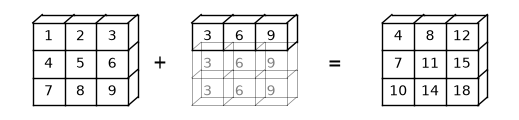

In [57]:
# Adapted and modified based on the code in the book written by Jake VanderPlas (see https://jakevdp.github.io/PythonDataScienceHandbook/06.00-figure-code.html#Broadcasting)
# Originally from astroML: see https://www.astroml.org/book_figures/appendix/fig_broadcast_visual.html


def draw_cube(ax, xy, size, depth=0.4,
              edges=None, label=None, label_kwargs=None, **kwargs):
    """draw and label a cube.  edges is a list of numbers between
    1 and 12, specifying which of the 12 cube edges to draw"""
    if edges is None:
        edges = range(1, 13)

    x, y = xy

    if 1 in edges:
        ax.plot([x, x + size],
                [y + size, y + size], **kwargs)
    if 2 in edges:
        ax.plot([x + size, x + size],
                [y, y + size], **kwargs)
    if 3 in edges:
        ax.plot([x, x + size],
                [y, y], **kwargs)
    if 4 in edges:
        ax.plot([x, x],
                [y, y + size], **kwargs)

    if 5 in edges:
        ax.plot([x, x + depth],
                [y + size, y + depth + size], **kwargs)
    if 6 in edges:
        ax.plot([x + size, x + size + depth],
                [y + size, y + depth + size], **kwargs)
    if 7 in edges:
        ax.plot([x + size, x + size + depth],
                [y, y + depth], **kwargs)
    if 8 in edges:
        ax.plot([x, x + depth],
                [y, y + depth], **kwargs)

    if 9 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth + size, y + depth + size], **kwargs)
    if 10 in edges:
        ax.plot([x + depth + size, x + depth + size],
                [y + depth, y + depth + size], **kwargs)
    if 11 in edges:
        ax.plot([x + depth, x + depth + size],
                [y + depth, y + depth], **kwargs)
    if 12 in edges:
        ax.plot([x + depth, x + depth],
                [y + depth, y + depth + size], **kwargs)

    if label:
        if label_kwargs is None:
            label_kwargs = {}
        ax.text(x + 0.5 * size, y + 0.5 * size, label,
                ha='center', va='center', **label_kwargs)

solid = dict(c='black', ls='-', lw=1,
             label_kwargs=dict(color='k'))
dotted = dict(c='black', ls='-', lw=0.5, alpha=0.5,
              label_kwargs=dict(color='gray'))
depth = 0.3

# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '12', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '15', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '14', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

در مورد `b -> (3, 1)` چطور؟

در این حالت، NumPy به طور خودکار `b -> (3, 1)` را به `b -> (3, 3)` گسترش می‌دهد.

جمع عنصر به عنصر سپس منجر به یک ماتریس $3 \times 3$ می‌شود

In [58]:
b.shape = (3, 1)

a + b

array([[ 4,  5,  6],
       [10, 11, 12],
       [16, 17, 18]])

در اینجا یک نمایش بصری از این عملیات broadcasting آورده شده است:

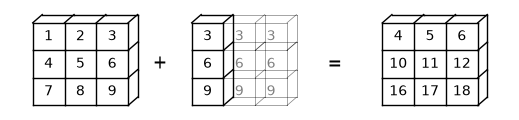

In [59]:
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '2', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3], '5', **solid)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 7, 10], '6', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3], '8', **solid)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10], '9', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '3', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '6', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '9', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '4', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '5', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '6', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '10', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '11', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '16', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '17', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '18', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');


در برخی موارد، هر دو عملوند گسترش داده می‌شوند.

وقتی `a -> (3,)` و `b -> (3, 1)` داریم، `a` به `a -> (3, 3)` گسترش داده خواهد شد، و `b` به `b -> (3, 3)` گسترش داده خواهد شد.

در این حالت، جمع عنصر به عنصر منجر به یک ماتریس $3 \times 3$ می‌شود

In [60]:
a = np.array([3, 6, 9])
b = np.array([2, 3, 4])
b.shape = (3, 1)

a + b

array([[ 5,  8, 11],
       [ 6,  9, 12],
       [ 7, 10, 13]])

در اینجا یک نمایش بصری از این عملیات broadcasting آورده شده است:

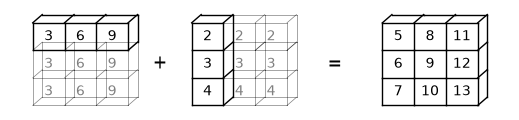

In [61]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(5, 1), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (3, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (1, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (3, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (3, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 7, 9, 10], '2', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **dotted)

draw_cube(ax, (6, 6.5), 1, depth, [2, 3, 4, 7, 10], '3', **solid)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '3', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 10], '4', **solid)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '4', **dotted)

# third block
draw_cube(ax, (12, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '5', **solid)
draw_cube(ax, (13, 7.5), 1, depth, [1, 2, 3, 6, 9], '8', **solid)
draw_cube(ax, (14, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '11', **solid)

draw_cube(ax, (12, 6.5), 1, depth, [2, 3, 4], '6', **solid)
draw_cube(ax, (13, 6.5), 1, depth, [2, 3], '9', **solid)
draw_cube(ax, (14, 6.5), 1, depth, [2, 3, 7, 10], '12', **solid)

draw_cube(ax, (12, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (13, 5.5), 1, depth, [2, 3], '10', **solid)
draw_cube(ax, (14, 5.5), 1, depth, [2, 3, 7, 10], '13', **solid)

ax.text(5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10.5, 7.0, '=', size=12, ha='center', va='center');

در حالی که broadcasting بسیار مفید است، گاهی اوقات می‌تواند گیج‌کننده به نظر برسد.

برای مثال، بیایید سعی کنیم `a -> (3, 2)` و `b -> (3,)` را جمع کنیم.

In [62]:
a = np.array(
      [[1, 2],
       [4, 5],
       [7, 8]])
b = np.array([3, 6, 9])

a + b

ValueError: operands could not be broadcast together with shapes (3,2) (3,) 

`ValueError` به ما می‌گوید که عملوندها نمی‌توانند با هم broadcast شوند.


در اینجا یک نمایش بصری برای نشان دادن اینکه چرا این broadcasting نمی‌تواند اجرا شود آورده شده است:

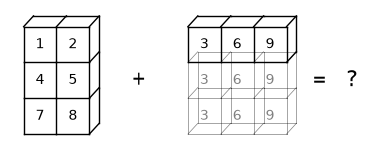

In [63]:
# Draw a figure and axis with no boundary
fig = plt.figure(figsize=(3, 1.3), facecolor='w')
ax = plt.axes([0, 0, 1, 1], xticks=[], yticks=[], frameon=False)

# first block
draw_cube(ax, (1, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '1', **solid)
draw_cube(ax, (2, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '2', **solid)

draw_cube(ax, (1, 6.5), 1, depth, [2, 3, 4], '4', **solid)
draw_cube(ax, (2, 6.5), 1, depth, [2, 3, 7, 10], '5', **solid)

draw_cube(ax, (1, 5.5), 1, depth, [2, 3, 4], '7', **solid)
draw_cube(ax, (2, 5.5), 1, depth, [2, 3, 7, 10], '8', **solid)

# second block
draw_cube(ax, (6, 7.5), 1, depth, [1, 2, 3, 4, 5, 6, 9], '3', **solid)
draw_cube(ax, (7, 7.5), 1, depth, [1, 2, 3, 6, 9], '6', **solid)
draw_cube(ax, (8, 7.5), 1, depth, [1, 2, 3, 6, 7, 9, 10], '9', **solid)

draw_cube(ax, (6, 6.5), 1, depth, range(2, 13), '3', **dotted)
draw_cube(ax, (7, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '6', **dotted)
draw_cube(ax, (8, 6.5), 1, depth, [2, 3, 6, 7, 9, 10, 11], '9', **dotted)

draw_cube(ax, (6, 5.5), 1, depth, [2, 3, 4, 7, 8, 10, 11, 12], '3', **dotted)
draw_cube(ax, (7, 5.5), 1, depth, [2, 3, 7, 10, 11], '6', **dotted)
draw_cube(ax, (8, 5.5), 1, depth, [2, 3, 7, 10, 11], '9', **dotted)


ax.text(4.5, 7.0, '+', size=12, ha='center', va='center')
ax.text(10, 7.0, '=', size=12, ha='center', va='center')
ax.text(11, 7.0, '?', size=16, ha='center', va='center');

می‌بینیم که NumPy نمی‌تواند آرایه‌ها را به یک اندازه گسترش دهد.

این به این دلیل است که، وقتی `b` از `b -> (3,)` به `b -> (3, 3)` گسترش می‌یابد، NumPy نمی‌تواند `b` را با `a -> (3, 2)` مطابقت دهد.

زمانی که به ابعاد بالاتر می‌رویم، موارد پیچیده‌تر می‌شوند.

برای کمک به ما، می‌توانیم از لیست قوانین زیر استفاده کنیم:

* *مرحله 1:* وقتی ابعاد دو آرایه مطابقت ندارند، NumPy ابعادی را به آن یک که ابعاد کمتری دارد با اضافه کردن بعد (ابعاد) در سمت چپ ابعاد موجود گسترش می‌دهد.
    - برای مثال، اگر `a -> (3, 3)` و `b -> (3,)` باشد، broadcasting یک بعد به سمت چپ اضافه خواهد کرد تا `b -> (1, 3)` شود؛
    - اگر `a -> (2, 2, 2)` و `b -> (2, 2)` باشد، broadcasting یک بعد به سمت چپ اضافه خواهد کرد تا `b -> (1, 2, 2)` شود؛
    - اگر `a -> (3, 2, 2)` و `b -> (2,)` باشد، broadcasting دو بعد به سمت چپ اضافه خواهد کرد تا `b -> (1, 1, 2)` شود (همچنین می‌توانید این فرآیند را به عنوان عبور از *مرحله 1* دو بار ببینید).


* *مرحله 2:* وقتی دو آرایه بعد یکسانی دارند اما شکل‌های متفاوت، NumPy سعی خواهد کرد ابعادی را که شاخص شکل آن‌ها 1 است گسترش دهد.
    - برای مثال، اگر `a -> (1, 3)` و `b -> (3, 1)` باشد، broadcasting ابعاد با شکل 1 را در هر دو `a` و `b` گسترش خواهد داد تا `a -> (3, 3)` و `b -> (3, 3)` شوند؛
    - اگر `a -> (2, 2, 2)` و `b -> (1, 2, 2)` باشد، broadcasting بعد اول `b` را گسترش خواهد داد تا `b -> (2, 2, 2)` شود؛
    - اگر `a -> (3, 2, 2)` و `b -> (1, 1, 2)` باشد، broadcasting `b` را در همه ابعاد با شکل 1 گسترش خواهد داد تا `b -> (3, 2, 2)` شود.

* *مرحله 3:* پس از مرحله 1 و 2، اگر دو آرایه هنوز مطابقت نداشته باشند، یک `ValueError` ایجاد خواهد شد. برای مثال، فرض کنید `a -> (2, 2, 3)` و `b -> (2, 2)` باشند
    - طبق *مرحله 1*، `b` به `b -> (1, 2, 2)` گسترش خواهد یافت؛
    - طبق *مرحله 2*، `b` به `b -> (2, 2, 2)` گسترش خواهد یافت؛
    - می‌بینیم که پس از دو مرحله اول، آن‌ها با یکدیگر مطابقت ندارند. بنابراین، یک `ValueError` ایجاد خواهد شد

## قابلیت تغییر و کپی کردن آرایه‌ها

آرایه‌های NumPy انواع داده قابل تغییر هستند، مانند لیست‌های Python.

به عبارت دیگر، محتویات آن‌ها می‌توانند پس از مقداردهی اولیه در حافظه تغییر یابند (جهش یابند).

این مناسب است اما، زمانی که با مدل نام‌گذاری و ارجاع Python ترکیب می‌شود،
می‌تواند منجر به اشتباهات توسط مبتدیان NumPy شود.

در این بخش برخی از موضوعات کلیدی را بررسی می‌کنیم.

### قابلیت تغییر

قبلاً نمونه‌هایی از قابلیت تغییر را در بالا دیدیم.

در اینجا یک مثال دیگر از جهش یک آرایه NumPy آورده شده است

In [64]:
a = np.array([42, 44])
a

array([42, 44])

In [65]:
a[-1] = 0  # عنصر آخر را به 0 تغییر دهید
a

array([42,  0])

قابلیت تغییر منجر به رفتار زیر می‌شود (که می‌تواند برای برنامه‌نویسان MATLAB شوکه‌کننده باشد...)

In [66]:
rng = np.random.default_rng()
a = rng.standard_normal(3)
a

array([0.06659573, 0.63505303, 1.18147425])

In [67]:
b = a
b[0] = 0.0
a

array([0.        , 0.63505303, 1.18147425])

آنچه اتفاق افتاده این است که ما `a` را با تغییر دادن `b` تغییر داده‌ایم.

نام `b` به `a` متصل است و صرفاً یک ارجاع دیگر به
آرایه می‌شود (مدل انتساب Python با جزئیات بیشتر {doc}`بعداً در دوره <python_advanced_features>` شرح داده شده است).

از این رو، حقوق برابری برای ایجاد تغییرات در آن آرایه دارد.

این در واقع معقول‌ترین رفتار پیش‌فرض است!

این به این معنی است که ما فقط اشاره‌گرها را به داده منتقل می‌کنیم، به جای ایجاد کپی.

ایجاد کپی از نظر سرعت و حافظه گران است.

### ایجاد کپی

البته هنگام نیاز می‌توان `b` را یک کپی مستقل از `a` ساخت.

این کار می‌تواند با استفاده از `np.copy` انجام شود

In [68]:
a = rng.standard_normal(3)
a

array([ 0.40324852, -0.72292693,  0.91765211])

In [69]:
b = np.copy(a)
b

array([ 0.40324852, -0.72292693,  0.91765211])

اکنون `b` یک کپی مستقل است (که *deep copy* نامیده می‌شود)

In [70]:
b[:] = 1
b

array([1., 1., 1.])

In [71]:
a

array([ 0.40324852, -0.72292693,  0.91765211])

توجه کنید که تغییر در `b` بر `a` تأثیر نگذاشته است.

## ویژگی‌های اضافی

بیایید نگاهی به برخی ویژگی‌های مفید دیگر NumPy بیندازیم.

### توابع جهانی

```{index} single: NumPy; Vectorized Functions
```

NumPy نسخه‌هایی از توابع استاندارد `log`، `exp`، `sin` و غیره را فراهم می‌کند که به صورت *عنصر به عنصر* روی آرایه‌ها عمل می‌کنند

In [72]:
z = np.array([1, 2, 3])
np.sin(z)

array([0.84147098, 0.90929743, 0.14112001])

این نیاز به حلقه‌های صریح عنصر به عنصر مانند موارد زیر را از بین می‌برد

In [73]:
n = len(z)
y = np.empty(n)
for i in range(n):
    y[i] = np.sin(z[i])

از آنجا که آن‌ها به صورت عنصر به عنصر روی آرایه‌ها عمل می‌کنند، این توابع گاهی اوقات **توابع برداری شده** نامیده می‌شوند.

در اصطلاح NumPy، آن‌ها همچنین **ufunc**ها، یا **توابع جهانی** نامیده می‌شوند.

همان‌طور که در بالا دیدیم، عملیات حسابی معمول (`+`، `*`، و غیره) نیز
به صورت عنصر به عنصر کار می‌کنند، و ترکیب این‌ها با ufunc ها مجموعه بسیار بزرگی از توابع سریع عنصر به عنصر را می‌دهد.

In [74]:
z

array([1, 2, 3])

In [75]:
(1 / np.sqrt(2 * np.pi)) * np.exp(- 0.5 * z**2)

array([0.24197072, 0.05399097, 0.00443185])

همه توابع تعریف شده توسط کاربر به صورت عنصر به عنصر عمل نخواهند کرد.

برای مثال، ارسال تابع `f` تعریف شده در زیر به یک آرایه NumPy باعث `ValueError` می‌شود

In [76]:
def f(x):
    return 1 if x > 0 else 0

تابع NumPy `np.where` یک جایگزین برداری شده ارائه می‌دهد:

In [77]:
x = rng.standard_normal(4)
x

array([ 0.35612417,  1.37535143,  0.26586937, -0.05957849])

In [78]:
np.where(x > 0, 1, 0)  # اگر x > 0 درست باشد 1 درج کنید، در غیر این صورت 0

array([1, 1, 1, 0])

همچنین می‌توانید از `np.vectorize` برای برداری کردن یک تابع داده شده استفاده کنید

In [79]:
f = np.vectorize(f)
f(x)                # ارسال همان بردار x مانند مثال قبلی

array([1, 1, 1, 0])

با این حال، این رویکرد همیشه همان سرعت یک تابع برداری شده با دقت بیشتر ساخته شده را به دست نمی‌آورد.

(بعداً خواهیم دید که JAX یک نسخه قدرتمند از `np.vectorize` دارد که می‌تواند و معمولاً کد بسیار کارآمدی تولید می‌کند.)

### مقایسه‌ها

```{index} single: NumPy; Comparisons
```

به عنوان یک قاعده، مقایسه‌ها روی آرایه‌ها به صورت عنصر به عنصر انجام می‌شوند

In [80]:
z = np.array([2, 3])
y = np.array([2, 3])
z == y

array([ True,  True])

In [81]:
y[0] = 5
z == y

array([False,  True])

In [82]:
z != y

array([ True, False])

وضعیت برای `>`، `<`، `>=` و `<=` مشابه است.

همچنین می‌توانیم مقایسه‌ها را با اسکالرها انجام دهیم

In [83]:
z = np.linspace(0, 10, 5)
z

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [84]:
z > 3

array([False, False,  True,  True,  True])

این به ویژه برای *استخراج شرطی* مفید است

In [85]:
b = z > 3
b

array([False, False,  True,  True,  True])

In [86]:
z[b]

array([ 5. ,  7.5, 10. ])

البته می‌توانیم --- و اغلب انجام می‌دهیم --- این کار را در یک مرحله انجام دهیم

In [87]:
z[z > 3]

array([ 5. ,  7.5, 10. ])

### بسته‌های فرعی

NumPy برخی از قابلیت‌های اضافی مرتبط با برنامه‌نویسی علمی را
از طریق بسته‌های فرعی خود ارائه می‌دهد.

قبلاً دیده‌ایم که چگونه می‌توانیم با استفاده از
[`Generator` تصادفی](https://numpy.org/doc/stable/reference/random/generator.html#random-generator) NumPy متغیرهای تصادفی تولید کنیم.

In [88]:
z = rng.standard_normal(10000)  # تولید توزیع نرمال استاندارد
y = rng.binomial(10, 0.5, size=1000)    # 1000 نمونه از Bin(10, 0.5)
y.mean()

np.float64(5.083)

یکی دیگر از بسته‌های فرعی رایج استفاده شده np.linalg است

In [89]:
A = np.array([[1, 2], [3, 4]])

np.linalg.det(A)           # محاسبه دترمینان

np.float64(-2.0000000000000004)

In [90]:
np.linalg.inv(A)           # محاسبه معکوس

array([[-2. ,  1. ],
       [ 1.5, -0.5]])

```{index} single: SciPy
```

```{index} single: Python; SciPy
```

بسیاری از این قابلیت‌ها همچنین در [SciPy](https://scipy.org/) موجود است، مجموعه‌ای از ماژول‌ها که روی NumPy ساخته شده‌اند.

نسخه‌های SciPy را به زودی با جزئیات بیشتر {doc}`پوشش خواهیم داد <scipy>`.

برای فهرست جامعی از آنچه در NumPy موجود است به [این مستندات](https://numpy.org/doc/stable/reference/routines.html) مراجعه کنید.

### چندنخی ضمنی

[قبلاً](need_for_speed) مفهوم موازی‌سازی از طریق چندنخی را مورد بحث قرار دادیم.

NumPy سعی می‌کند چندنخی را در بسیاری از کد کامپایل شده خود پیاده‌سازی کند.

بیایید نگاهی به یک مثال بیندازیم تا این را در عمل ببینیم.

قطعه کد بعدی مقادیر ویژه تعداد زیادی ماتریس تولید شده تصادفی را محاسبه می‌کند.

اجرای آن چند ثانیه طول می‌کشد.

In [91]:
n = 20
m = 1000
for i in range(n):
    X = rng.standard_normal((m, m))
    λ = np.linalg.eigvals(X)

اکنون، بیایید نگاهی به خروجی مانیتور سیستم htop در دستگاه ما در حالی که
این کد در حال اجرا است بیندازیم:

```{figure} /_static/lecture_specific/parallelization/htop_parallel_npmat.png
:scale: 80
```

می‌بینیم که 4 مورد از 8 CPU با سرعت کامل در حال اجرا هستند.

این به این دلیل است که روتین `eigvals` NumPy به زیبایی وظایف را تقسیم می‌کند و
آن‌ها را به نخ‌های مختلف توزیع می‌کند.

## تمرین‌ها


```{exercise-start}
:label: np_ex1
```

عبارت چندجمله‌ای زیر را در نظر بگیرید

```{math}
:label: np_polynom

p(x) = a_0 + a_1 x + a_2 x^2 + \cdots a_N x^N = \sum_{n=0}^N a_n x^n
```

{ref}`قبلاً <pyess_ex2>`، یک تابع ساده `p(x, coeff)` برای ارزیابی {eq}`np_polynom` بدون در نظر گرفتن کارایی نوشتید.

اکنون یک تابع جدید بنویسید که همان کار را انجام می‌دهد، اما از آرایه‌های NumPy و عملیات آرایه برای محاسبات خود استفاده می‌کند، به جای هر شکلی از حلقه Python.

(چنین قابلیتی قبلاً به عنوان `np.poly1d` پیاده‌سازی شده است، اما به خاطر تمرین از این کلاس استفاده نکنید)

```{hint}
:class: dropdown
از `np.cumprod()` استفاده کنید
```
```{exercise-end}
```

```{solution-start} np_ex1
:class: dropdown
```

این کد کار را انجام می‌دهد

In [92]:
def p(x, coef):
    X = np.ones_like(coef)
    X[1:] = x
    y = np.cumprod(X)   # y = [1, x, x**2,...]
    return coef @ y

بیایید آن را تست کنیم

In [93]:
x = 2
coef = np.linspace(2, 4, 3)
print(coef)
print(p(x, coef))
# برای مقایسه
q = np.poly1d(np.flip(coef))
print(q(x))

[2. 3. 4.]
24.0
24.0


```{solution-end}
```


```{exercise-start}
:label: np_ex2
```

فرض کنید `q` یک آرایه NumPy با طول `n` با `q.sum() == 1` باشد.

فرض کنید که `q` یک [تابع جرم احتمال](https://en.wikipedia.org/wiki/Probability_mass_function) را نمایش می‌دهد.

می‌خواهیم یک متغیر تصادفی گسسته $x$ تولید کنیم به طوری که $\mathbb P\{x = i\} = q_i$.

به عبارت دیگر، `x` مقادیری را در `range(len(q))` می‌گیرد و `x = i` با احتمال `q[i]`.

الگوریتم استاندارد (تبدیل معکوس) به صورت زیر است:

* فاصله واحد $[0, 1]$ را به $n$ زیر فاصله $I_0, I_1, \ldots, I_{n-1}$ تقسیم کنید به طوری که طول $I_i$ برابر با $q_i$ باشد.
* یک متغیر تصادفی یکنواخت $U$ در $[0, 1]$ رسم کنید و $i$ ای را برگردانید که $U \in I_i$.

احتمال رسم $i$ برابر با طول $I_i$ است که برابر با $q_i$ است.

می‌توانیم الگوریتم را به صورت زیر پیاده‌سازی کنیم

In [94]:
from random import uniform

def sample(q):
    a = 0.0
    U = uniform(0, 1)
    for i in range(len(q)):
        if a < U <= a + q[i]:
            return i
        a = a + q[i]

اگر نمی‌توانید ببینید این چگونه کار می‌کند، سعی کنید جریان را برای یک مثال ساده، مانند `q = [0.25, 0.75]` به خوبی بررسی کنید
رسم فواصل روی کاغذ کمک می‌کند.

تمرین شما این است که آن را با استفاده از NumPy سریع‌تر کنید و از حلقه‌های صریح اجتناب کنید

```{hint}
:class: dropdown

از `np.searchsorted` و `np.cumsum` استفاده کنید

```

اگر می‌توانید، قابلیت را به عنوان یک کلاس به نام `DiscreteRV` پیاده‌سازی کنید، جایی که

* داده‌های یک نمونه از کلاس، بردار احتمالات `q` است
* کلاس یک متد `draw()` دارد که یک نمونه را مطابق با الگوریتم توصیف شده در بالا برمی‌گرداند

اگر می‌توانید، متد را طوری بنویسید که `draw(k)` `k` نمونه از `q` برگرداند.

```{exercise-end}
```

```{solution-start} np_ex2
:class: dropdown
```

در اینجا اولین تلاش ما برای یک راه‌حل آورده شده است:

In [95]:
from numpy import cumsum

class DiscreteRV:
    """
    یک آرایه از نمونه‌ها را از یک متغیر تصادفی گسسته با بردار
    احتمالات داده شده توسط q تولید می‌کند.
    """

    def __init__(self, q, seed=None):
        """
        آرگومان q یک آرایه NumPy است، یا شبیه آرایه، غیر منفی و جمع
        به 1 می‌شود
        """
        self.q = q
        self.Q = cumsum(q)
        self.rng = np.random.default_rng(seed)

    def draw(self, k=1):
        """
        k نمونه از q برمی‌گرداند. برای هر چنین نمونه‌ای، مقدار i با
        احتمال q[i] برگردانده می‌شود.
        """
        return self.Q.searchsorted(self.rng.uniform(0, 1, size=k))

منطق واضح نیست، اما اگر وقت خود را بگذارید و آن را به آرامی بخوانید،
درک خواهید کرد.

با این حال، در اینجا یک مشکل وجود دارد.

فرض کنید که `q` پس از ایجاد یک نمونه از `discreteRV` تغییر کند،
برای مثال با

In [96]:
q = (0.1, 0.9)
d = DiscreteRV(q)
d.q = (0.5, 0.5)

مشکل این است که `Q` بر این اساس تغییر نمی‌کند، و `Q` داده‌ای است که در متد `draw` استفاده می‌شود.

برای مقابله با این موضوع، یک گزینه محاسبه `Q` هر بار که متد draw فراخوانی می‌شود است.

اما این نسبت به محاسبه یک‌بار `Q` ناکارآمد است.

یک گزینه بهتر استفاده از descriptors است.

یک راه‌حل از [کتابخانه quantecon](https://github.com/QuantEcon/QuantEcon.py/tree/main/quantecon)
با استفاده از descriptors که همان‌طور که می‌خواهیم رفتار می‌کند را می‌توان
[در اینجا](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/discrete_rv.py) یافت.

```{solution-end}
```


```{exercise}
:label: np_ex3

{ref}`بحث قبلی <oop_ex1>` ما در مورد تابع توزیع تجمعی تجربی را به خاطر بیاورید.

وظیفه شما این است که

1. متد `__call__` را با استفاده از NumPy کارآمدتر کنید.
1. یک متد اضافه کنید که ECDF را روی $[a, b]$ رسم می‌کند، جایی که $a$ و $b$ پارامترهای متد هستند.
```

```{solution-start} np_ex3
:class: dropdown
```

یک راه‌حل مثال در زیر داده شده است.

در واقع، ما فقط [این کد](https://github.com/QuantEcon/QuantEcon.py/blob/main/quantecon/ecdf.py) را از QuantEcon گرفته‌ایم
و یک متد plot به آن اضافه کرده‌ایم

In [97]:
"""
ecdf.py را از QuantEcon اصلاح می‌کند تا یک متد plot اضافه کند

"""

class ECDF:
    """
    تابع توزیع تجربی یک بعدی با توجه به یک بردار از
    مشاهدات.

    پارامترها
    ----------
    observations : array_like
        یک آرایه از مشاهدات

    ویژگی‌ها
    ----------
    observations : array_like
        یک آرایه از مشاهدات

    """

    def __init__(self, observations):
        self.observations = np.asarray(observations)

    def __call__(self, x):
        """
        ecdf را در x ارزیابی می‌کند

        پارامترها
        ----------
        x : scalar(float)
            x که ecdf در آن ارزیابی می‌شود

        برمی‌گرداند
        -------
        scalar(float)
            کسری از نمونه کمتر از x

        """
        return np.mean(self.observations <= x)

    def plot(self, ax, a=None, b=None):
        """
        ecdf را روی فاصله [a, b] رسم کنید.

        پارامترها
        ----------
        a : scalar(float), optional(default=None)
            نقطه انتهای پایین فاصله رسم
        b : scalar(float), optional(default=None)
            نقطه انتهای بالای فاصله رسم

        """

        # === انتخاب فاصله معقول اگر [a, b] مشخص نشده باشد === #
        if a is None:
            a = self.observations.min() - self.observations.std()
        if b is None:
            b = self.observations.max() + self.observations.std()

        # === تولید رسم === #
        x_vals = np.linspace(a, b, num=100)
        f = np.vectorize(self.__call__)
        ax.plot(x_vals, f(x_vals))
        plt.show()

در اینجا یک مثال از استفاده آورده شده است

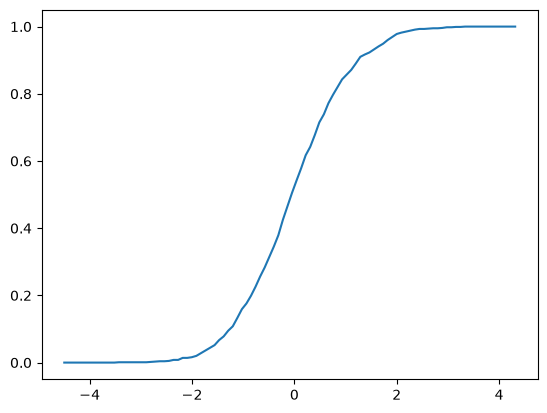

In [98]:
fig, ax = plt.subplots()
rng = np.random.default_rng()
X = rng.standard_normal(1000)
F = ECDF(X)
F.plot(ax)

```{solution-end}
```


```{exercise-start}
:label: np_ex4
```

به یاد بیاورید که [broadcasting](broadcasting) در Numpy می‌تواند به ما کمک کند عملیات عنصر به عنصر را روی آرایه‌ها با تعداد متفاوتی از ابعاد بدون استفاده از حلقه‌های `for` انجام دهیم.

در این تمرین، سعی کنید از حلقه‌های `for` برای تکرار نتیجه عملیات broadcasting زیر استفاده کنید.

**قسمت 1**: سعی کنید این مثال ساده را با استفاده از حلقه‌های `for` تکرار کنید و نتایج خود را با عملیات broadcasting زیر مقایسه کنید.

In [99]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)
A = x / y

در اینجا خروجی آورده شده است

In [100]:
print(A)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


**قسمت 2**: به سمت تکرار نتیجه عملیات broadcasting زیر حرکت کنید. در عین حال، سرعت broadcasting و حلقه `for` که پیاده‌سازی می‌کنید را مقایسه کنید.

برای این قسمت از تمرین می‌توانید از توابع `tic`/`toc` از کتابخانه `quantecon` برای زمان‌سنجی اجرا استفاده کنید.

بیایید مطمئن شویم که این کتابخانه نصب شده است.

In [101]:
!pip install quantecon

اکنون می‌توانیم بسته quantecon را import کنیم.

In [102]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("Broadcasting operation"):
    B = x / y

Broadcasting operation: 0.0115 seconds elapsed


در اینجا خروجی آورده شده است

In [103]:
print(B)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

```{exercise-end}
```


```{solution-start} np_ex4
:class: dropdown
```

**راه‌حل قسمت 1**

In [104]:
rng = np.random.default_rng(123)
x = rng.standard_normal((4, 4))
y = rng.standard_normal(4)

C = np.empty_like(x)
n = len(x)
for i in range(n):
    for j in range(n):
        C[i, j] = x[i, j] / y[j]

نتایج را برای بررسی پاسخ خود مقایسه کنید

In [105]:
print(C)

[[-0.64562663  0.55727833 -4.13068155  0.57428108]
 [ 0.60065994 -0.87444021  2.04128976  1.60450491]
 [-0.20665053  0.488491   -0.31163862 -4.51767283]
 [ 0.77815951  1.01684966 -3.20810109  0.40359261]]


همچنین می‌توانید از `array_equal()` برای بررسی پاسخ خود استفاده کنید

In [106]:
print(np.array_equal(A, C))

True


**راه‌حل قسمت 2**

In [107]:
rng = np.random.default_rng(123)
x = rng.standard_normal((1000, 100, 100))
y = rng.standard_normal(100)

with qe.Timer("For loop operation"):
    D = np.empty_like(x)
    d1, d2, d3 = x.shape
    for i in range(d1):
        for j in range(d2):
            for k in range(d3):
                D[i, j, k] = x[i, j, k] / y[k]

For loop operation: 3.8551 seconds elapsed


توجه کنید که حلقه `for` مدت زمان بسیار بیشتری نسبت به عملیات broadcasting طول می‌کشد.

نتایج را برای بررسی پاسخ خود مقایسه کنید

In [108]:
print(D)

[[[ 1.11459186e+00  6.49554639e-01 -1.39222984e+00 ...  1.29919811e+00
    4.05186703e+00 -7.40287138e+01]
  [ 5.81192956e-01 -2.92842384e+00  3.21336857e-01 ...  1.20991613e+00
    2.27427587e+00  1.44385102e+02]
  [ 1.05593413e+00  1.42938670e+00  4.45508796e-01 ...  4.01152744e-01
    2.84732007e+00  8.92867644e+01]
  ...
  [-2.74886903e-02  1.26977472e+00  3.14108995e-01 ...  1.11710121e-01
    1.42995646e+00 -3.11820183e+01]
  [ 2.37232237e-02 -1.07344880e+00 -6.84853323e-02 ...  1.34568899e-01
   -1.03734701e-01 -1.06565258e+02]
  [-1.74039841e+00 -3.01228229e+00 -9.49433502e-01 ...  1.44494147e-01
   -7.23108571e+00 -2.90325461e+01]]

 [[ 5.31486218e-01  2.93920784e+00 -2.44783577e-01 ... -6.32917660e-01
   -2.52543447e+00 -5.31568329e+01]
  [-4.73496558e-01  1.49038936e-01  1.68780916e+00 ...  2.05750194e-01
   -1.40524927e+00 -6.14593964e-01]
  [-2.74888585e+00 -2.33570490e+00  3.41515715e-01 ...  1.24702883e-01
   -1.68468042e+00  8.33959001e+01]
  ...
  [-8.36506904e-01 -1.8

In [109]:
print(np.array_equal(B, D))

True


```{solution-end}
```